## Ejemplo MLP con TensorFlow
<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a usar Keras y Tensorflow para resolver un problema de clasificación de imágenes con une red neuronal. 
    <p>Keras es una API de machine learning que permite construir, entrenar, evaluar y ejecutar redes neuronales. Hay dos tipos de implementaciones de Keras. La que usa distintos backends para realizar los cálculos (TensorFlow, Microsoft Cognitive Toolkit (CNTK), Theano...) y la que usa solo TensorFlow. Vamos a usar esta última porque tiene más funcionalidades de TensorFlow que la otra y porque permite hacer todo lo que necesitamos.</p>
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Para Deep Learning la librería que más se usa es PyTorch. La API es muy similar a la de Keras ya que ambas se inspiran en Scikit-Learn.
</div>

In [20]:
#Instalamos tensoflow
!pip install -U tensorflow

<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a solucionar un problema incluido en el set de MNIST. Esta vez no va a ser el de las imágenes de números sino el de imágenes de rop (Fashion MNIST). Son 70000 imágenes en blanco y negro de 28x28 que represetan artículos de moda. Es un poco más complicado de resolver que MNIST normal. Modelos sencillos que alcanzan el 92% en MNIST alcanzan el 83% con este problema.
</div>

In [21]:
import tensorflow as tf
from tensorflow import keras
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

<div style="border-style:groove;border-width:thin;padding:10px">
Los datos serán matrices de 28x28 y cada dato será un entero en vez de un float.
</div>

In [22]:
X_train_full.shape

(60000, 28, 28)

<div style="border-style:groove;border-width:thin;padding:10px">
Como vamos a usar el Descenso de Gradiente debemos escalar las variables de entrada. Además, como lo vamos a dividir entre 255.0 estamos convirtiendo los datos a float.
</div>

In [23]:
from sklearn.model_selection import train_test_split
X_train_full = X_train_full/255.0
X_test = X_test/255.0

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size = 0.1, random_state = 0)

<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a ver que clases tenemos entre manos. En MNIST la clase 5 era un 5, pero ahora será otra cosa.
</div>


In [15]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
"Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
class_names[y_train[0]]

'Coat'

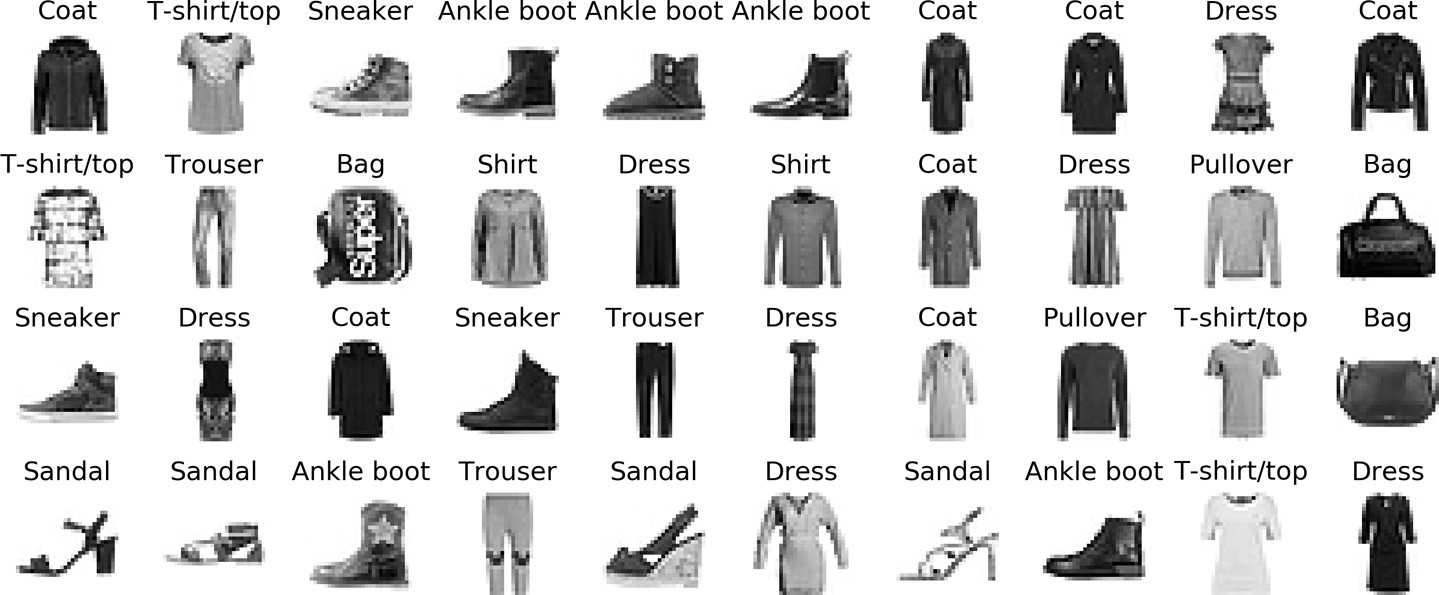


<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a construir el modelo. Por capas, como hicimos gráficamente.
</div>

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(530,activation='relu'))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))



c:\Users\Equipo\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<div style="border-style:groove;border-width:thin;padding:10px">
Expliquemos un poco el código anterior:
    <ul>
        <li>La primera línea crea el modelo, en este caso es secuencial, es decir, la salida de cada capa está conectada a la entrada de la siguiente.</li>
        <li>La primera capa es la de entrada. En este caso la capa flatten lo que hace es preparar los datos. Los convierte en un array de 1D indicándole nosotros que la entrada es de 28x28. También se podría haber usado InputLayer.</li>
        <li>Después estamos metiendo una capa de tipo Dense (todas las salidas de la capa anterior se conectan a todas las entradas de esta capa) de 300 neuronas. Definimos como función de activación una ReLU. También tendrá el array de sesgos (uno por neurona).</li>
        <li>Tras esta capa metemos otra capa de 100 neuronas con activación ReLU.</li>
        <li>Finalmente añadimos una capa de salida de 10 neuronas (porque tenemos 10 clases) y ponemos softmax como activación porque solo puede estar activa una. Las clases son exclusivas.</li>
    </ul>  
</div>

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 530)            │       416,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        53,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,160 (1.79 MB)

 Trainable params: 470,160 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

<div style="border-style:groove;border-width:thin;padding:10px">
Cuando tenemos capas densas siempre tenemos muchos parámetros que ajustar. En este caso son 784 entradas x 300 conexiones + 300 sesgos = 235500 parámetros a calcular. Ojo! Si nos hemos pasado puede que hagamos overfitting.
</div>

In [31]:
#veamos las capas del modelo.
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [ ]:
#podemos dar nombre de variable a una capa.
hidden1 = model.layers[1]

In [32]:
#Así es más fácil ver sus parámetros.
weights, biases = hidden1.get_weights()
print(weights)
print(weights.shape)
print(biases)
print(biases.shape)

[[-0.00408752 -0.01690662 -0.01907765 ...  0.02093031  0.02793673
   0.01608615]
 [ 0.00713918 -0.01644775  0.01315162 ... -0.01067968  0.03752352
   0.04013123]
 [ 0.00537571  0.0356812  -0.02749185 ...  0.06331743 -0.01296948
  -0.00498758]
 ...
 [ 0.05720279  0.00666215  0.02581985 ...  0.05084147  0.05398973
   0.00956243]
 [-0.05499062  0.00828025  0.05045996 ... -0.05318925  0.00088147
  -0.01815169]
 [ 0.02862758 -0.03763945 -0.01195157 ... -0.04138661 -0.05320998
  -0.01193764]]
(784, 530)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

<div style="border-style:groove;border-width:thin;padding:10px">
Todavía no hemos entrenado el modelo. Lo que estamos viendo son los valores de inicialización. En el caso de los pesos son aleatorios y en el caso de los sesgos, todos a 0. Para darles valores de inicialización se pueden usar los métodos kernel_initializer y bias_initializer.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Ahora nos queda "compilar" el modelo. En este momento hay que indicar la función de pérdida, el optimizador y la métrica que quieres que use para valorar el resultado. 
</div>

In [34]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=keras.optimizers.SGD(learning_rate=0.01),metrics=['accuracy'])

<div style="border-style:groove;border-width:thin;padding:10px">
Expliquemos un poco este código:
    <ul>
        <li>Se usa como función de pérdida "sparse_categorical_crossentropy" porque hay escasas (sparse) etiquetas (10) y porque son mutuamente excluyentes. Si tuvieramos una clasificación binaria usaríamos "sigmoid" como activación a la salida y "binary_crossentropy" como función de pérdida.</li>
        <li>El optimizador será el descenso de gradiente, pero si queremos podemos usar otra forma: optimizer=keras.optimiz ers.SGD(lr="0.1") nos permite ajustar el learning rate, que por defecto es 0.01.</li>
    </ul>
</div>

In [ ]:
history = model.fit(X_train, y_train, epochs=30,
                    validation_split=0.1)

Epoch 1/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9256 - loss: 0.2087 - val_accuracy: 0.9213 - val_loss: 0.2182
Epoch 2/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9271 - loss: 0.2053 - val_accuracy: 0.9120 - val_loss: 0.2366
Epoch 3/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9274 - loss: 0.2014 - val_accuracy: 0.9187 - val_loss: 0.2207
Epoch 4/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9297 - loss: 0.1977 - val_accuracy: 0.9189 - val_loss: 0.2261
Epoch 5/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9307 - loss: 0.1931 - val_accuracy: 0.9131 - val_loss: 0.2359
Epoch 6/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9320 - loss: 0.1907 - val_accuracy: 0.9219 - val_loss: 0.2187
Epoch 7/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9345 - loss: 0.1857 - val_accuracy: 0.9213 - val_loss: 0.2200
Epoch 8/30
1519/1519 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9338 - loss: 0.1827 - 

<div style="border-style:groove;border-width:thin;padding:10px">
Hemos pasado un validation_data para que nos de valores de validación (es opcional). Así, en cada época, podemos ver los valores de accuracy en training y en validación. Si el valor en validación es mucho peor o comienza a bajar... estamos haciendo Overfitting!. También podemos usar un parámetro para hacer esto mismo que es validation_split="0.1" que reserva un 10% (correctamente mezclado) para validación.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Si hay clases que tienen mucha más representación que otras o no todas tienen la misma importancia puedes utilizar el parámetro de fit llamado class_weight. 
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Fíjate en que el método fit() devuelve un objeto History que contiene los parámetros del entrenamiento (history.params), la lista de épocas (history.epoch) y un diccinoario con las métricas de las épocas (history.history). 
</div>

In [38]:
history.history

{'accuracy': [0.9256378412246704,
  0.927139937877655,
  0.9274280071258545,
  0.9296913743019104,
  0.9306584596633911,
  0.9320370554924011,
  0.9345473051071167,
  0.9338065981864929,
  0.9364197254180908,
  0.9363991618156433,
  0.937674880027771,
  0.9392798542976379,
  0.9410082101821899,
  0.9423251152038574,
  0.9443004131317139,
  0.944526731967926,
  0.9456995725631714,
  0.9467900991439819,
  0.948888897895813,
  0.9484156370162964,
  0.9491357803344727,
  0.950226366519928,
  0.9518107175827026,
  0.9531275629997253,
  0.9535596966743469,
  0.9541357755661011,
  0.9553909301757812,
  0.9562757015228271,
  0.9570987820625305,
  0.956810712814331],
 'loss': [0.2086787223815918,
  0.20525075495243073,
  0.20136618614196777,
  0.1977175772190094,
  0.1930876076221466,
  0.19071350991725922,
  0.18567690253257751,
  0.18273060023784637,
  0.17876239120960236,
  0.17738793790340424,
  0.1737392544746399,
  0.17021161317825317,
  0.1666509360074997,
  0.1640898883342743,
  0.16107

<div style="border-style:groove;border-width:thin;padding:10px">
Lo normal es que el resultado sea así. Es decir, que la precisión sea mejor en el training set que en el de validación. Como la accuracy sigue subiendo en el set de validación podemos seguir entrenando. El proceso está guardado. Si vuelves a entrenar con fit() seguirá por donde lo dejó. Si ves que ha ido mal, en cambio, tendrás que volver a cambiar los hiperparámetros y correr el código de nuevo sobreescribiendo history. También puedes meter más capas o cambiar el número de neuronas por capa.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a usar el método evaluate que utiliza los conjuntos de test y de train para darte una métrica del resultado. También puedes usar predict para ver a que clase pertenecen datos nuevos.
</div>

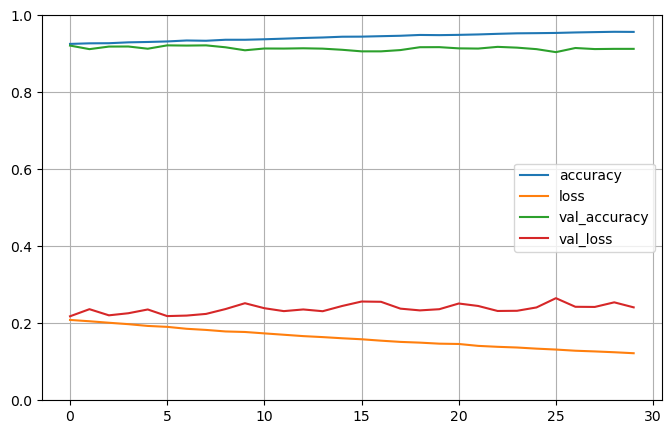

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [40]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8911 - loss: 0.3358


[0.33576998114585876, 0.8910999894142151]